# 05 · Business Impact & Retention ROI

A model is only worth deploying if acting on it **saves more than it costs**. This notebook translates the churn scores from notebook 03 into dollars: how much a targeted retention program saves, how many employees to contact, and how sensitive the answer is to the (uncertain) business assumptions.

### Contents
1. [Cost model & assumptions](#assumptions)
2. [Expected-value framework & break-even](#breakeven)
3. [How many to contact? Net-savings curve](#curve)
4. [The realistic case: capacity-constrained targeting](#capacity)
5. [Sensitivity analysis](#sensitivity)
6. [Recommendations](#recommendations)

In [1]:
# Make the package importable from a fresh checkout (no install needed).
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'employee_churn').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from employee_churn.data import make_synthetic_employee_data
from employee_churn.features.engineer_structured import (
    add_career_progression_features, add_tenure_bands,
    add_promotion_velocity, add_compensation_features, add_team_metrics,
)
from employee_churn.features.engineer_text import add_text_statistics
from employee_churn.nlp.sentiment import add_sentiment_scores
from employee_churn.nlp.emotion import add_emotion_features
from employee_churn.models.train import build_model_zoo, tune_hyperparameters
from sklearn.model_selection import train_test_split

df = make_synthetic_employee_data(n=1500, seed=42)
f = add_career_progression_features(df, 'hire_date', 'last_promotion_date')
f = add_tenure_bands(f)
f = add_promotion_velocity(f, 'num_promotions')
f = add_compensation_features(f, 'monthly_salary', 'department')
f = add_team_metrics(f, 'team_id')
f = add_sentiment_scores(f, 'feedback')
f = add_emotion_features(f, 'feedback')
f = add_text_statistics(f, 'feedback')
DROP = ['employee_id', 'churned', 'feedback', 'gender', 'department',
        'hire_date', 'last_promotion_date', 'team_id', 'tenure_band',
        'emotion_dominant']
X = f.drop(columns=DROP).select_dtypes(include=['number', 'bool'])
y = f['churned']
idx = np.arange(len(f))
X_tr, X_te, y_tr, y_te, _, i_te = train_test_split(
    X, y, idx, test_size=0.25, random_state=0, stratify=y)
best, _, _ = tune_hyperparameters(
    build_model_zoo(0)['random_forest'], X_tr, y_tr,
    model_name='random_forest', n_iter=5)
best.fit(X_tr, y_tr)
proba = best.predict_proba(X_te)[:, 1]
y_true = y_te.values
base_rate = y_true.mean()
print('held-out employees:', len(y_te), '| churn rate:', round(base_rate, 3))

held-out employees: 375 | churn rate: 0.451


<a id="assumptions"></a>
## 1 · Cost model & assumptions

We attach a dollar value to each decision with three transparent assumptions (every organization should plug in its own):

| Quantity | Assumption | Rationale |
|---|---|---|
| **Replacement cost** | 50% of annual salary | Industry estimates span 0.5–2x salary (recruiting, onboarding, lost productivity); we take the conservative end. |
| **Intervention cost** | \$4,000 per employee | Manager time, a retention package or development budget. |
| **Effectiveness** | 25% | Share of would-be churners actually retained by the intervention. |

Replacement cost is **salary-linked per employee**, so losing a higher-paid person is correctly treated as more expensive.

In [3]:
REPLACEMENT_FRAC = 0.5        # of annual salary
INTERVENTION_COST = 4_000.0   # $ per contacted employee
EFFECTIVENESS = 0.25          # P(retain | would-be churner, contacted)

annual_salary = f.iloc[i_te]['monthly_salary'].values * 12
replacement_cost = REPLACEMENT_FRAC * annual_salary
print(f'avg annual salary    : ${annual_salary.mean():,.0f}')
print(f'avg replacement cost : ${replacement_cost.mean():,.0f}')
print(f'intervention cost    : ${INTERVENTION_COST:,.0f}')
print(f'effectiveness        : {EFFECTIVENESS:.0%}')

avg annual salary    : $80,849
avg replacement cost : $40,425
intervention cost    : $4,000
effectiveness        : 25%


<a id="breakeven"></a>
## 2 · Expected-value framework

Contacting an employee with churn probability *p* has expected value

$$ \mathbb{E}[\text{value}] = p \cdot \text{effectiveness} \cdot \text{replacement\_cost} - \text{intervention\_cost}. $$

Setting this to zero gives a **break-even churn probability** below which intervening loses money on average.

In [4]:
p_star = INTERVENTION_COST / (EFFECTIVENESS * replacement_cost.mean())
print(f'break-even churn probability p* = {p_star:.3f}')
print(f'employees scored at or above p*: {(proba >= p_star).sum()} of {len(proba)}')

break-even churn probability p* = 0.396
employees scored at or above p*: 253 of 375


**Break-even sits at p\* ≈ 0.40.** With the average replacement cost (~\$40k), an intervention pays for itself once a person's churn probability clears ~40%. About **250 of the 375 held-out employees** score above that line — already a hint that a *broad* program is justified here, but the ranking tells us whom to prioritize when capacity is limited.

<a id="curve"></a>
## 3 · How many to contact?

Walking down the risk ranking, we accumulate the **realized** net savings (back-tested against the true churn labels): each contacted employee who *actually* churned returns `effectiveness × replacement_cost`; everyone contacted costs `intervention_cost`.

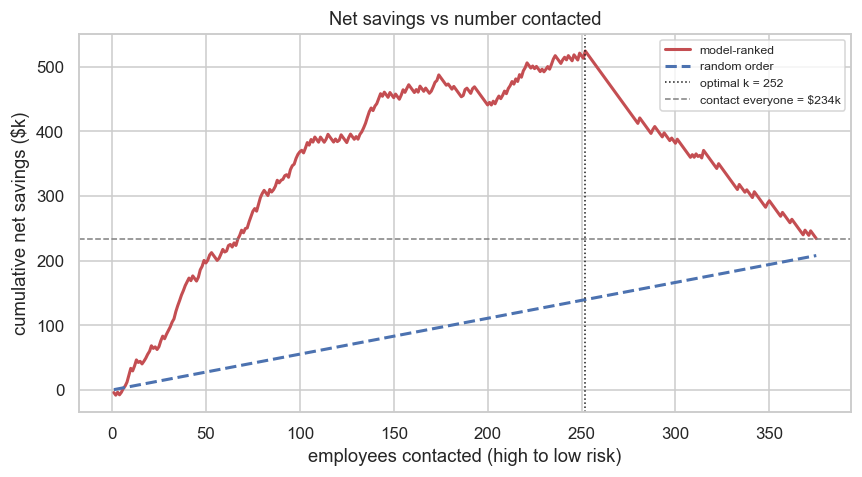

optimal: contact top 252 -> net $524,349


In [5]:
order = np.argsort(-proba)
benefit = np.where(y_true[order] == 1, EFFECTIVENESS * replacement_cost[order], 0.0)
net_model = np.cumsum(benefit - INTERVENTION_COST)
k = np.arange(1, len(y_true) + 1)
exp_random = k * (base_rate * EFFECTIVENESS * replacement_cost.mean()
                  - INTERVENTION_COST)
k_star = int(np.argmax(net_model)) + 1

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k, net_model / 1000, color='#c44e52', lw=2, label='model-ranked')
ax.plot(k, exp_random / 1000, color='#4c72b0', lw=2, ls='--', label='random order')
ax.axvline(k_star, color='k', lw=1, ls=':', label=f'optimal k = {k_star}')
ax.axhline(net_model[-1] / 1000, color='gray', lw=1, ls='--',
           label=f'contact everyone = ${net_model[-1]/1000:,.0f}k')
ax.set_xlabel('employees contacted (high to low risk)')
ax.set_ylabel('cumulative net savings ($k)')
ax.set_title('Net savings vs number contacted'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'optimal: contact top {k_star} -> net ${net_model[k_star-1]:,.0f}')

**Two lessons from the curve.** First, the model-ranked curve rises far faster than the random-order line — front-loading true churners is exactly what a good ranking does. Second, because the intervention here is cheap relative to the ~\$40k replacement cost, the *unconstrained* optimum is broad: net savings peak at **~\$520k around the top ~250 employees**, and even contacting everyone stays net-positive. In other words, with these assumptions the binding question is not *whether* to act but *whom to prioritize first* — which is where a finite budget comes in.

<a id="capacity"></a>
## 4 · The realistic case: limited capacity

HR rarely has the bandwidth to run a meaningful intervention for hundreds of people at once. Suppose the budget covers the **top 20%** (75 of 375). Where you spend that fixed budget is precisely what the model decides.

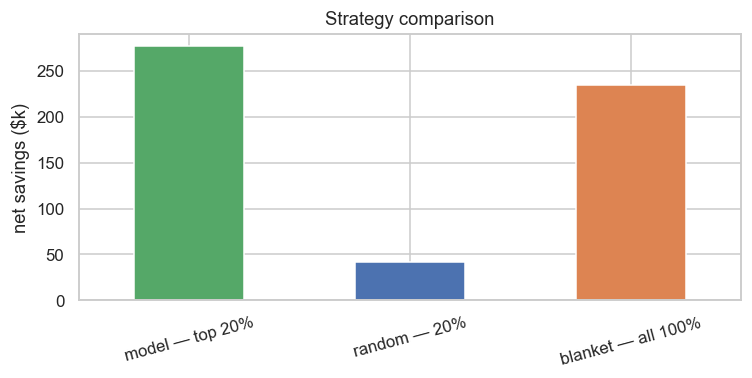

model top-20%  net = $276,328  (ROI 1.92x on spend)
random 20%     net = $41,588
blanket 100%   net = $234,167
model vs random uplift = $234,740 (6.6x)


In [6]:
K = int(0.20 * len(y_true))
model_net = net_model[K - 1]
random_net = K * (base_rate * EFFECTIVENESS * replacement_cost.mean()
                  - INTERVENTION_COST)
blanket_net = net_model[-1]
gross = benefit[:K].sum()
roi = gross / (K * INTERVENTION_COST)

strategies = pd.Series({
    'model — top 20%': model_net,
    'random — 20%': random_net,
    'blanket — all 100%': blanket_net,
})
fig, ax = plt.subplots(figsize=(7, 3.6))
(strategies / 1000).plot.bar(
    ax=ax, color=['#55a868', '#4c72b0', '#dd8452'])
ax.set_ylabel('net savings ($k)'); ax.set_title('Strategy comparison')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print(f'model top-20%  net = ${model_net:,.0f}  (ROI {roi:.2f}x on spend)')
print(f'random 20%     net = ${random_net:,.0f}')
print(f'blanket 100%   net = ${blanket_net:,.0f}')
print(f'model vs random uplift = ${model_net - random_net:,.0f} '
      f'({model_net / max(random_net, 1):.1f}x)')

**This is the model's dollar value.** Given a fixed budget for 75 interventions, **model targeting nets ~\$276k versus ~\$42k for random selection — a 6.6x uplift** — and every \$1 spent returns ~\$1.9 in avoided replacement cost. Strikingly, the model's top-20% program even **beats blanket outreach to all 375 employees (~\$234k) while contacting one-fifth as many people** and burning one-fifth of the manager time. Targeting is not just cheaper — under realistic capacity limits it is the *better-performing* strategy.

<a id="sensitivity"></a>
## 5 · Sensitivity analysis

The dollar figures hinge on two genuinely uncertain inputs — intervention effectiveness and cost. We recompute the optimal net savings across a grid to see where the program stops paying off.

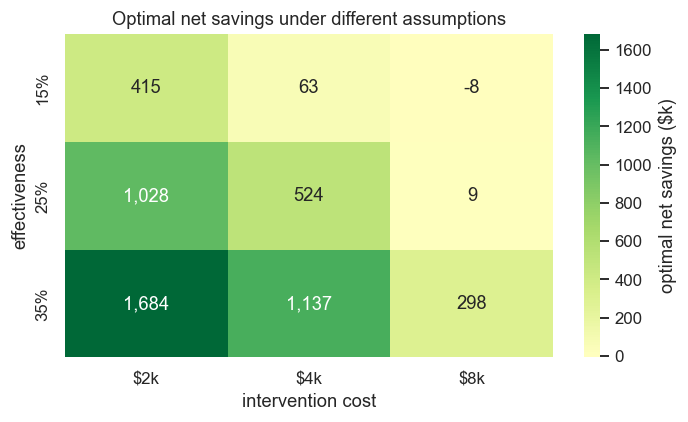

In [7]:
effects = [0.15, 0.25, 0.35]
costs = [2_000, 4_000, 8_000]
grid = np.zeros((len(effects), len(costs)))
for r, e in enumerate(effects):
    for c, ic in enumerate(costs):
        ben = np.where(y_true[order] == 1, e * replacement_cost[order], 0.0)
        grid[r, c] = np.cumsum(ben - ic).max()

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(grid / 1000, annot=True, fmt=',.0f', cmap='RdYlGn', center=0,
            xticklabels=[f'${c//1000}k' for c in costs],
            yticklabels=[f'{int(e*100)}%' for e in effects], ax=ax,
            cbar_kws={'label': 'optimal net savings ($k)'})
ax.set_xlabel('intervention cost'); ax.set_ylabel('effectiveness')
ax.set_title('Optimal net savings under different assumptions')
plt.tight_layout(); plt.show()

**The program is robust except in the worst corner.** Across most of the grid the optimal policy still saves six figures, but the value swings widely: from **~\$1.7M** (35% effectiveness, \$2k intervention) down to **roughly break-even or negative** when effectiveness is low (15%) and interventions are expensive (\$8k). The practical implication is that **measuring intervention effectiveness is as important as improving the model** — a small, well-run pilot to estimate that 15–35% number would de-risk the whole program.

<a id="recommendations"></a>
## 6 · Recommendations

1. **Deploy as a ranked worklist, not a blanket alarm.** Under realistic capacity limits, model-targeted outreach delivers a ~6.6x uplift over random and even beats contacting everyone.
2. **Set the cutoff from economics, not 0.5.** Intervene above the break-even probability (~0.40 here), adjusted for available budget.
3. **Instrument effectiveness.** The ROI is most sensitive to how often interventions actually work — run a holdout/pilot to measure it.
4. **Pair with the fairness controls from notebook 04** so targeting savings are not achieved through disparate treatment.
5. **Revisit the cost assumptions per role/region** — replacement cost is salary-linked, so the ranking and the budget should be too.